# ___Summaries of hOUwie model fits___
-------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.5.3 (2026-03-11 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("ggplot2")
})

source("../helpers.R")

In [3]:
options(repr.plot.width = 30, repr.plot.height = 12)

In [ ]:
# find out the AIC and AICc of all the models

# OUwie::getModelAvgParams()
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

# look up to see what the BIC stuff is about https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

# ___`hOUwie`___
------------------------------

In [ ]:
# the following are model fits for data that had
# - log transformed RD & SRL values
# - 5 mycorrhizal states (no ErM or OrM)
# - 995 unique plant species from FRED 3.0
# - mycorrhizal state information from FungalRoot
# - nsims set to 100 when fitting hOUwie models

In [6]:
length(unique(read.csv("../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states_name_matched_with_phylogeny.csv")$binominal)) # 995 species

[1] 995

In [21]:
dir("./../../data/chapter2/rdata/parallel/", recursive = FALSE, full.names = TRUE) # serialized model folders

[1] "./../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS" 
[2] "./../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS"

In [3]:
# root diameter (RD)
rd_cd <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = TRUE, regstrip = "_CD.Rds") # 12 models
rd_cid <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/LOG_RD_995SP_100SIMS/", cd = FALSE, regstrip = "_CID.Rds") # 12 models 

# specific root length (SRL)
srl_cd <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS/", cd = TRUE, regstrip = "_CD.Rds") # 12 models
srl_cid <- readallRds(dirpath = "./../../data/chapter2/rdata/parallel/LOG_SRL_995SP_100SIMS/", cd = FALSE, regstrip = "_CID.Rds") # 12 models

## ___Root diameter___
----------------------

In [24]:
OUwie::getModelTable(rd_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUMF00679,27,-837.7815,-222.4381,-610.7957,1731.127,14.5409887,3.748617e-04
ARDOUMAF00679,31,-1240.7399,-224.6911,-1009.8106,2545.540,828.9543658,5.324186e-181
ARDOUMVF00679,31,-875.8786,-222.4858,-648.7782,1815.817,99.2318326,1.525766e-22
ARDOUMVAF00679,35,-1214.4508,-225.2339,-984.6957,2501.529,784.9436965,1.918884e-171
EROUMF00679,8,-1307.4927,-235.9841,-1065.8242,2631.131,914.5458396,1.381341e-199
EROUMAF00679,12,-1254.1331,-235.9806,-1017.0206,2532.584,815.9983010,3.464391e-178
EROUMVF00679,12,-1238.7481,-235.9414,-999.0268,2501.814,785.2283279,1.664339e-171
EROUMVAF00679,16,-1221.0799,-235.9916,-980.3370,2474.716,758.1305515,1.274821e-165
SYMOUMF00679,17,-841.1358,-225.8393,-610.8337,1716.898,0.3124422,4.608511e-01


In [61]:
failed_convergence(model_table = OUwie::getModelTable(rd_cd, type = "AICc"), stripoff = "F00679") # none :)

character(0)

Using tip_state as id variables



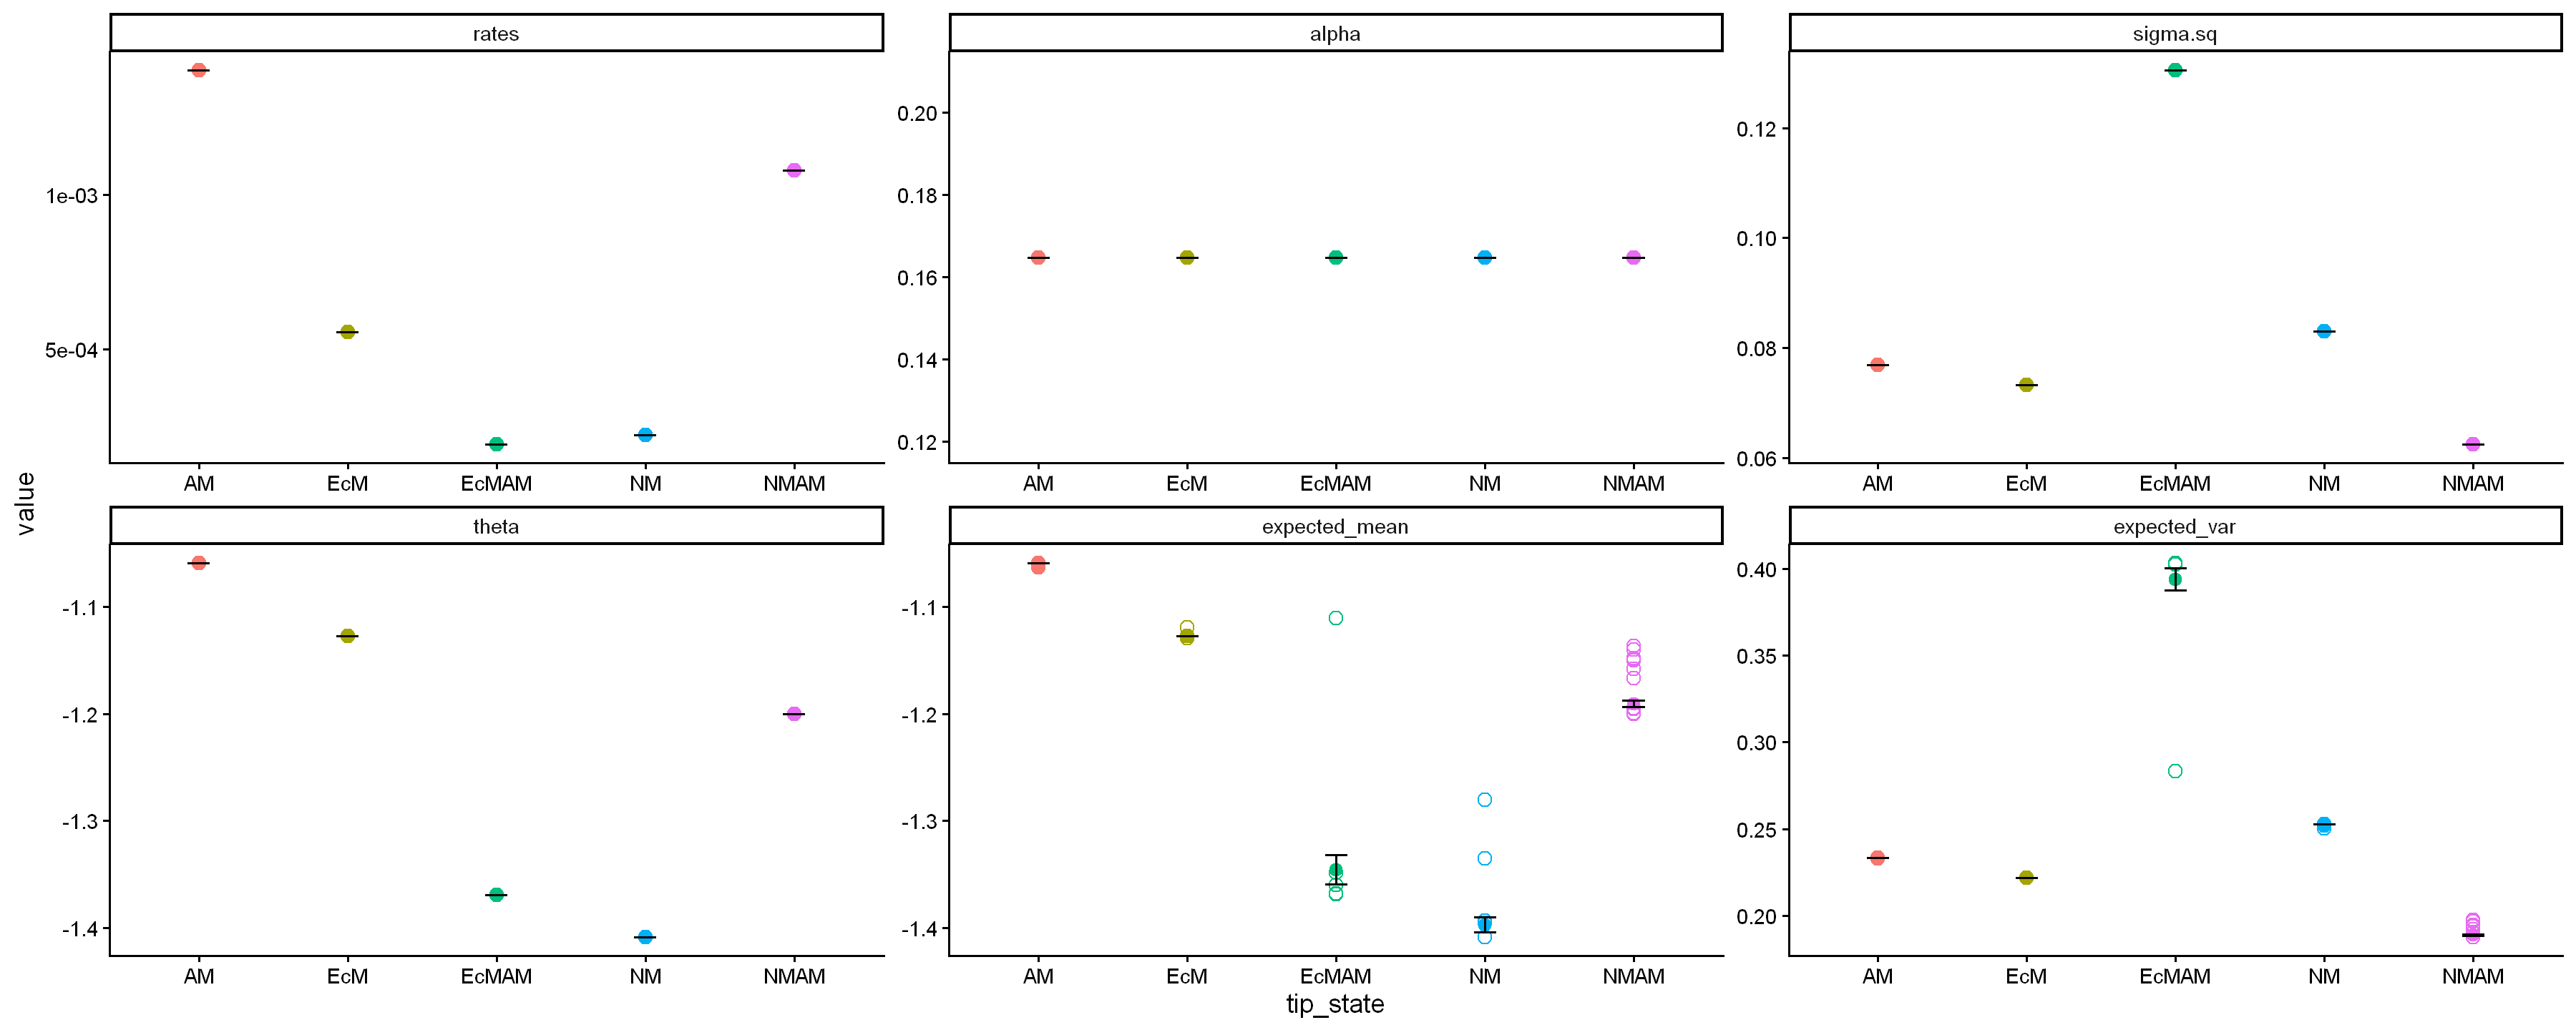

In [26]:
capture.output(df <- OUwie::getModelAvgParams(rd_cd, type = "AICc", force = FALSE), file = nullfile())
plot_df <- reshape2::melt(df)

plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")

plot(plt)

In [27]:
OUwie::getModelTable(rd_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUMF00679,46,-8.660587e+02,-244.8339,-6.175052e+02,1.828679e+03,18253609577,0
ARDOUMAF00679,47,-1.297129e+03,-245.0929,-1.054712e+03,2.693023e+03,18253610441,0
ARDOUMVF00679,47,-1.285349e+03,-244.7591,-1.039078e+03,2.669462e+03,18253610417,0
ARDOUMVAF00679,48,-1.277052e+03,-245.2749,-1.044505e+03,2.655076e+03,18253610403,0
EROUMF00679,8,-8.584728e+02,-236.2650,-6.178687e+02,1.733092e+03,18253609481,0
EROUMAF00679,9,4.294540e+09,-236.6196,-8.320778e+03,-8.589081e+09,9664527211,0
EROUMVF00679,9,-8.728444e+02,-236.0431,-6.322679e+02,1.763872e+03,18253609512,0
EROUMVAF00679,10,9.126804e+09,-242.6438,8.589933e+09,-1.825361e+10,0,1
SYMOUMF00679,26,-8.853430e+02,-248.2156,-1.078624e+03,1.824136e+03,18253609572,0


In [62]:
failed_convergence(model_table = OUwie::getModelTable(rd_cid, type = "AICc"), stripoff = "F00679") # welp

[1] "EROUMA"  "EROUMVA"

Using tip_state as id variables



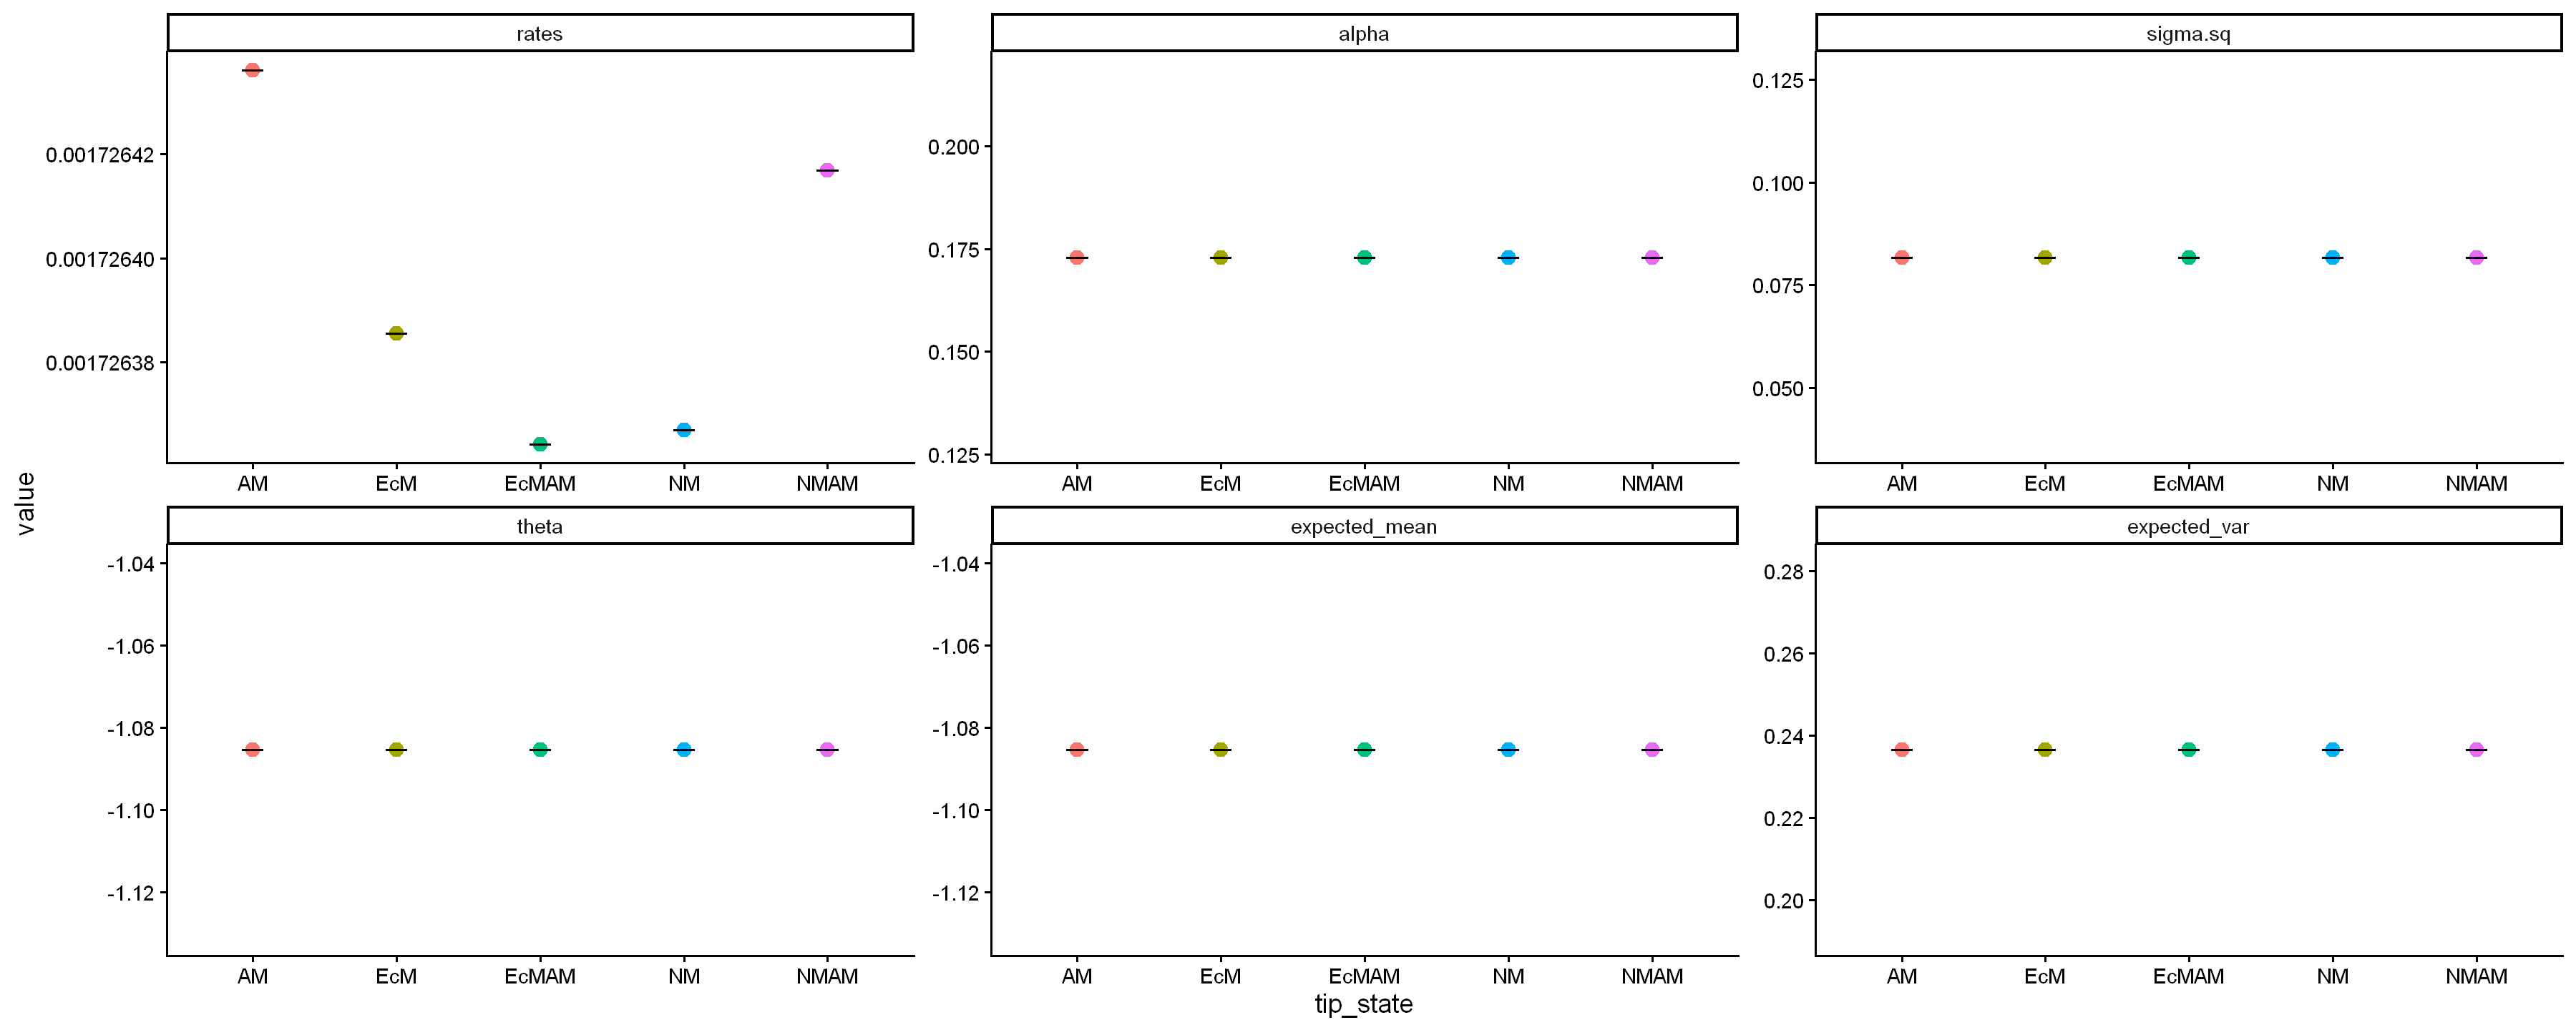

In [28]:
capture.output(df <- OUwie::getModelAvgParams(rd_cid, type = "AICc", force = FALSE), file = nullfile())
plot_df <- reshape2::melt(df)

plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")

plot(plt)

In [10]:
rbind(OUwie::getModelTable(rd_cd, type = "AICc")["AICc"], OUwie::getModelTable(rd_cid, type = "AICc")["AICc"])

,AICc
,<dbl>
ARDOUMF00679,1.731127e+03
ARDOUMAF00679,2.545540e+03
ARDOUMVF00679,1.815817e+03
ARDOUMVAF00679,2.501529e+03
EROUMF00679,2.631131e+03
EROUMAF00679,2.532584e+03
EROUMVF00679,2.501814e+03
EROUMVAF00679,2.474716e+03
SYMOUMF00679,1.716898e+03


## ___Specific root length___
----------------------

In [29]:
OUwie::getModelTable(srl_cd, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUMF00727,27,-1898.815,-222.4386,-1671.813,3853.194,31.503764,8.816617e-08
ARDOUMAF00727,31,-2211.673,-224.2157,-1983.303,4487.406,665.715792,1.690090e-145
ARDOUMVF00727,31,-2221.894,-222.3920,-1995.005,4507.848,686.158003,6.150923e-150
ARDOUMVAF00727,35,-2164.539,-225.2221,-1934.445,4401.705,580.014976,6.880272e-127
EROUMF00727,8,-1904.484,-235.9440,-1664.636,3825.114,3.424010,1.103426e-01
EROUMAF00727,12,-2234.623,-235.9917,-1992.989,4493.565,671.874426,7.772836e-147
EROUMVF00727,12,-1898.686,-235.9516,-1658.743,3821.690,0.000000,6.113043e-01
EROUMVAF00727,16,-2198.069,-236.0035,-1958.364,4428.694,607.004213,9.483473e-133
SYMOUMF00727,17,-1894.319,-225.8475,-1664.442,3823.263,1.573409,2.783531e-01


In [67]:
failed_convergence(model_table = OUwie::getModelTable(srl_cd, type = "AICc"), stripoff = "F00727") # none :)

character(0)

Using tip_state as id variables



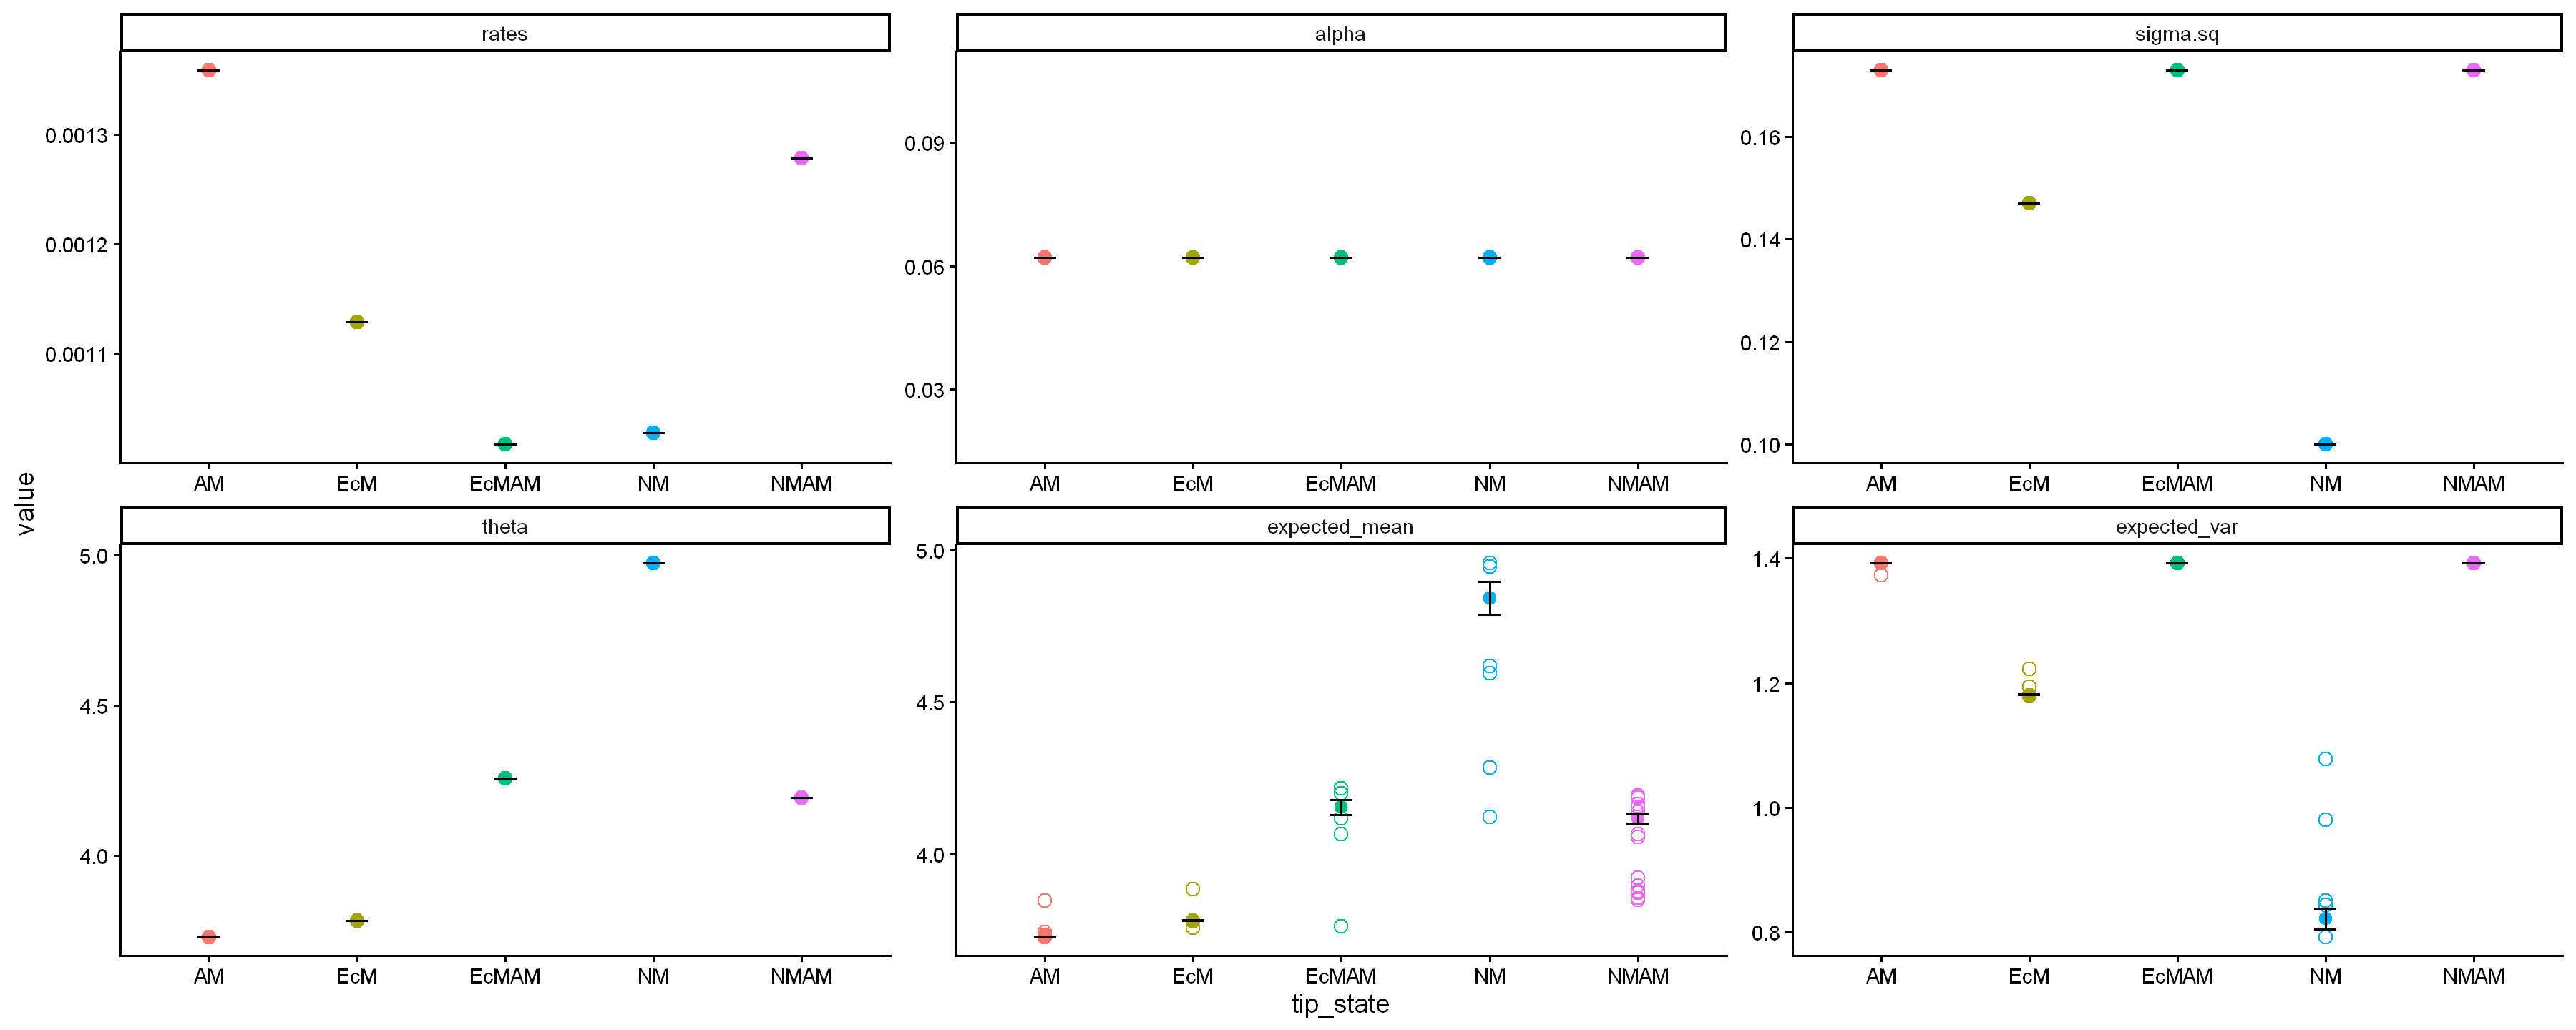

In [30]:
capture.output(df <- OUwie::getModelAvgParams(srl_cd, type = "AICc", force = FALSE), file = nullfile())
plot_df <- reshape2::melt(df)

plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")

plot(plt)

In [31]:
OUwie::getModelTable(srl_cid, type = "AICc")

,np,lnLik,DiscLik,ContLik,AICc,dAICc,AICcwt
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUMF00727,46,-2.280617e+03,-265.4901,-2025.149,4.657795e+03,17179870052,0
ARDOUMAF00727,47,-2.174983e+03,-262.8171,-2053.463,4.448731e+03,17179869842,0
ARDOUMVF00727,47,-2.249811e+03,-260.8590,-2026.660,4.598387e+03,17179869992,0
ARDOUMVAF00727,48,-2.085369e+03,-268.5176,-1833.000,4.271710e+03,17179869665,0
EROUMF00727,8,-2.265167e+03,-235.9243,-2024.658,4.546480e+03,17179869940,0
EROUMAF00727,9,8.589933e+09,-236.3958,536869234.335,-1.717987e+10,0,1
EROUMVF00727,9,-1.913447e+03,-235.9671,-1673.154,3.845077e+03,17179869239,0
EROUMVAF00727,10,-2.144410e+03,-237.5550,-2013.270,4.309044e+03,17179869703,0
SYMOUMF00727,26,-1.919728e+03,-250.2099,-1734.309,3.892906e+03,17179869287,0


In [66]:
failed_convergence(model_table = OUwie::getModelTable(srl_cid, type = "AICc"), stripoff = "F00727") # damn

[1] "EROUMA"  "SYMOUMA"

Using tip_state as id variables



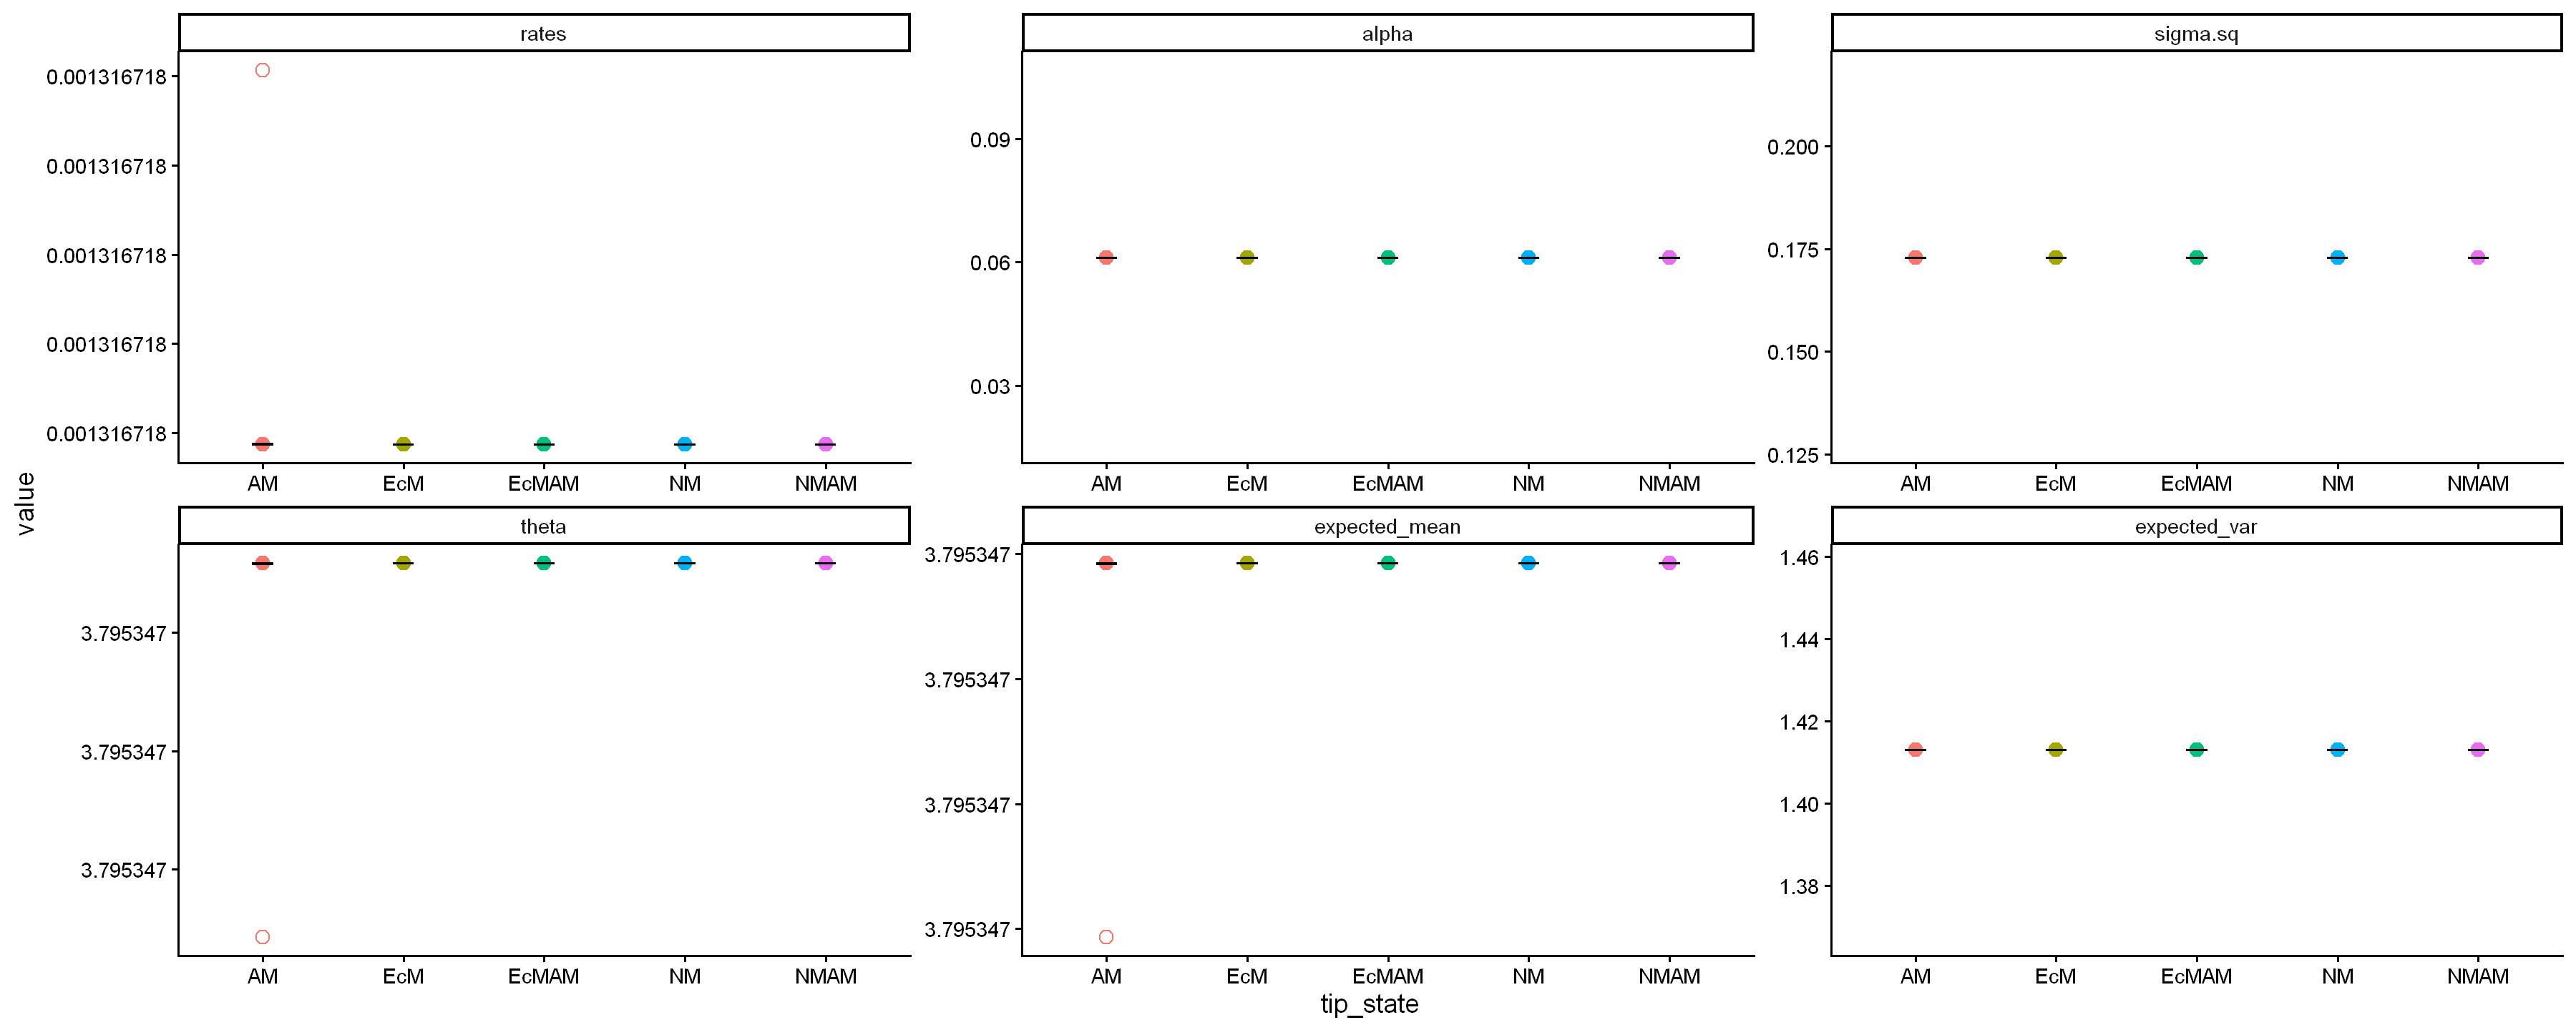

In [32]:
capture.output(df <- OUwie::getModelAvgParams(srl_cid, type = "AICc", force = FALSE), file = nullfile())
plot_df <- reshape2::melt(df)

plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")

plot(plt)

Warning message in OUwie::getModelAvgParams(srl_cid, type = "AICc", force = TRUE):
"It is possible that one or more of your models failed to converge. The AIC between the best and worst models exceeds 1e10. Set force=FALSE to automatically remove potentially failed runs."
Using tip_state as id variables



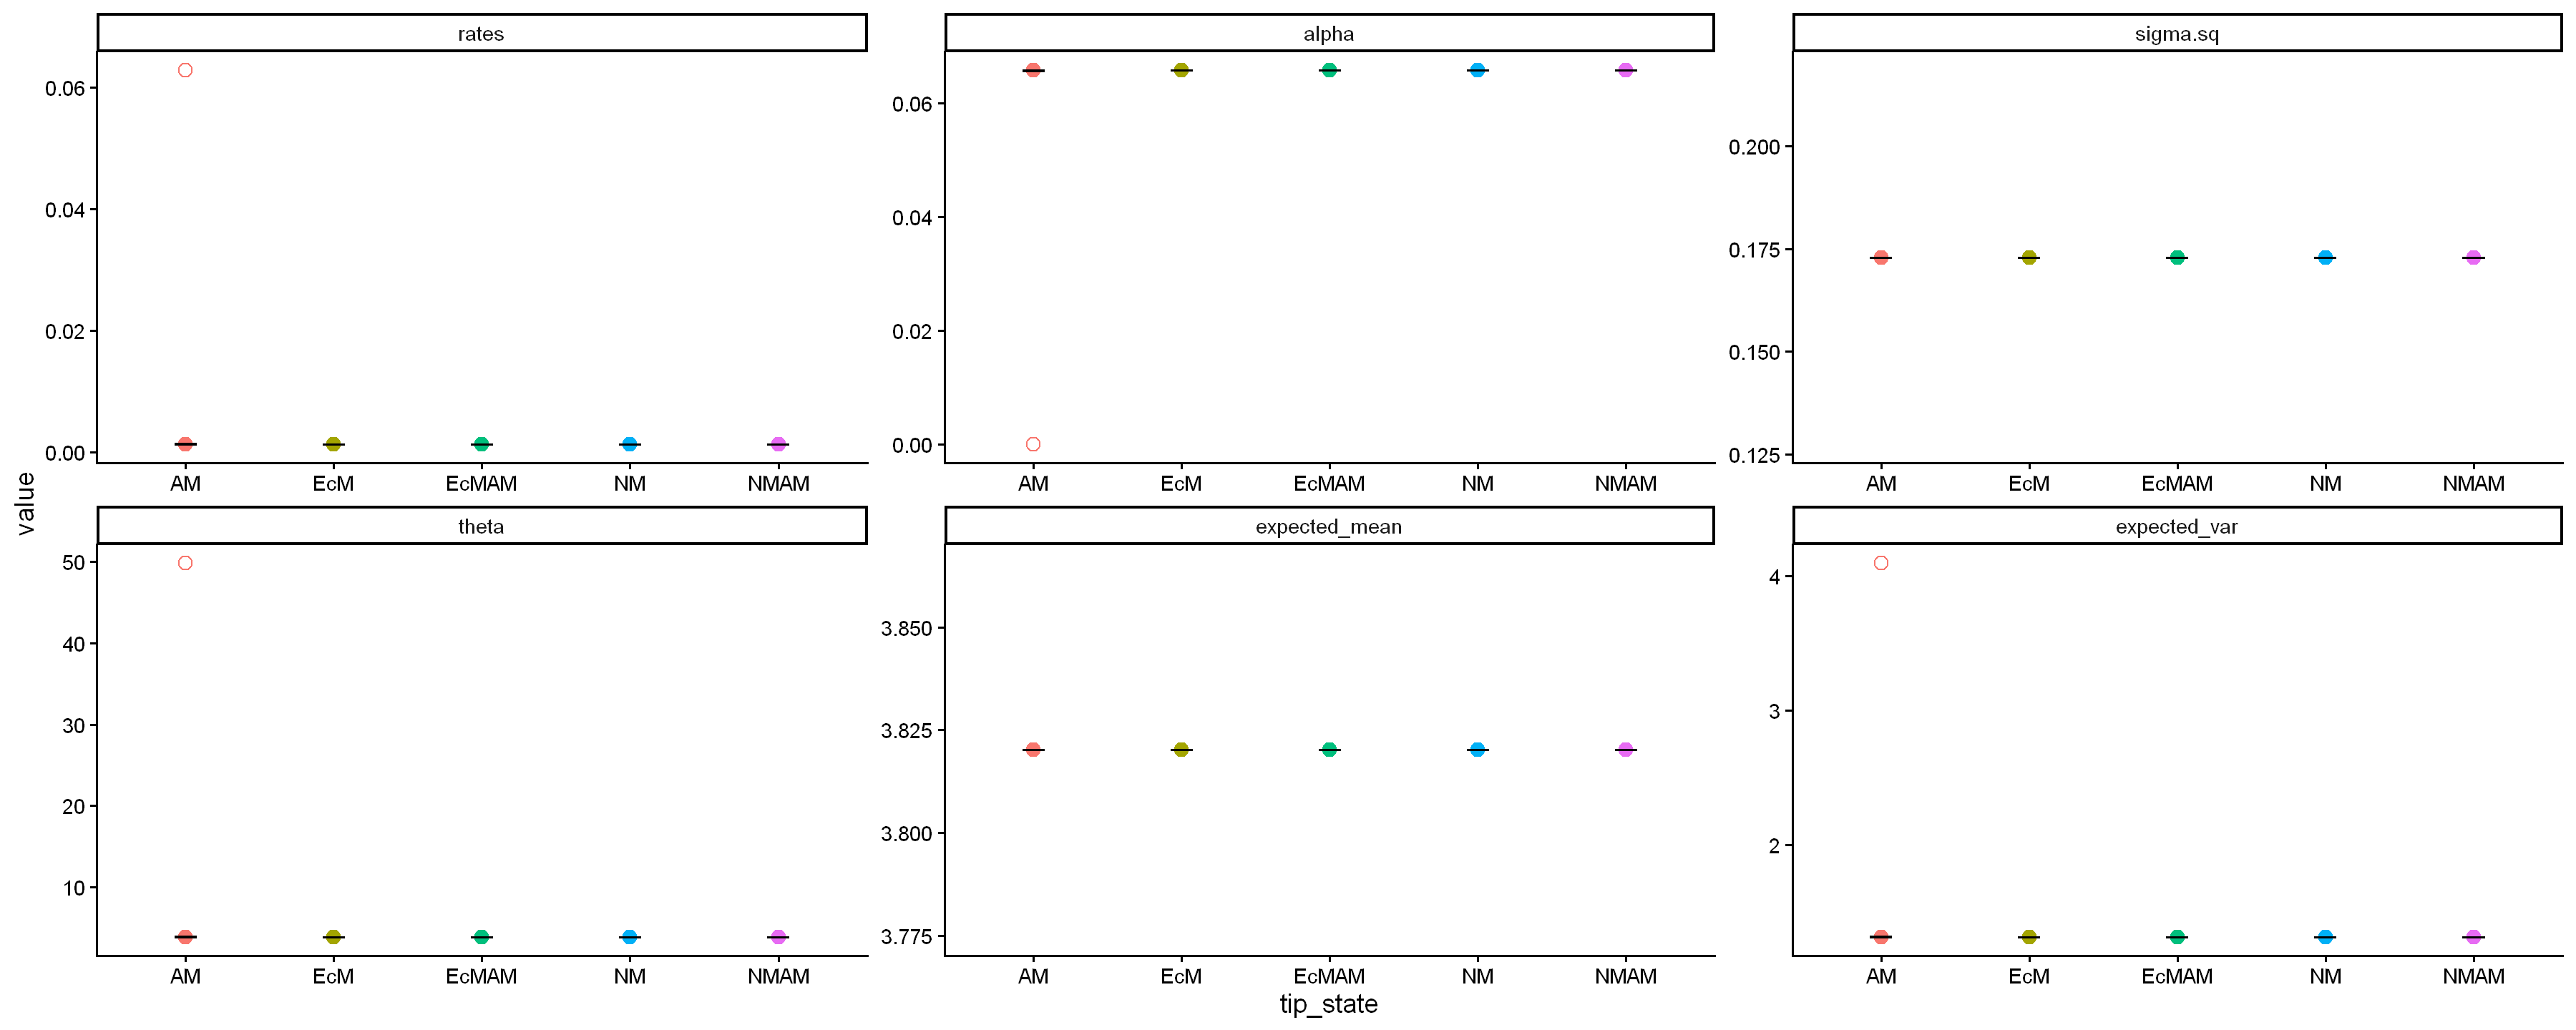

In [33]:
# try including the failed to converge models as well - doesn't seem to make a difference

capture.output(df <- OUwie::getModelAvgParams(srl_cid, type = "AICc", force = TRUE), file = nullfile())
plot_df <- reshape2::melt(df)

plt <- ggplot(plot_df, aes(x = tip_state, y = value, color = tip_state)) +
    geom_point(size = 5, shape = 21) +
    stat_summary(fun = mean, geom = "point", aes(group = 1, size = 2)) +
    stat_summary(fun.data = "mean_se", geom = "errorbar", aes(group = 1), width = 0.15, color = "black") +
    theme_classic(base_size = 22) +
    theme(legend.position = "none") +
    facet_wrap(~variable, scales = "free")

plot(plt)

In [ ]:
# so the criteria is that the absoulte difference AICc of a given model and the model with the highest AICc (worst fit) shouldn't exceed 1e5, else it's considered a convergence failure